# ***Домашняя работа №2***
## Еськина Ева Руслановна 
### БФБО-02-24

## ***2.3.1. Загрузка данных и первичный осмотр***

### ***Задание 1***
>Импортировать необходимые библиотеки:
>- pandas (обязательно),
>- при необходимости numpy,
>- matplotlib.pyplot для визуализации.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### ***Задание 2***
>Загрузить учебный датасет в pandas.DataFrame с помощью pd.read_csv (или другого подходящего метода).

In [6]:
df = pd.read_csv('S02-hw-dataset.csv')

### ***Задание 3***
>Вывести:
>- первые строки датасета (head()),
> - информацию о столбцах и типах (info()),
> - базовые описательные статистики (describe() или аналог).

In [8]:
df.head(5)

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


In [10]:
df.describe()

,user_id,age,purchases,revenue
count,41.000000,39.000000,41.000000,41.000000
mean,20.243902,36.512821,4.829268,820.048780
std,11.659289,18.304259,2.710189,613.127269
min,1.000000,5.000000,-1.000000,0.000000
25%,10.000000,24.000000,3.000000,432.000000
50%,20.000000,33.000000,5.000000,693.000000
75%,30.000000,45.500000,7.000000,1115.000000
max,40.000000,120.000000,11.000000,2475.000000


In [11]:
df.mode()

,user_id,age,country,purchases,revenue
0,10.0,24.0,RU,6,0.0
1,NaN,NaN,NaN,7,NaN


## ***2.3.2. Пропуски, дубликаты и базовый контроль качества***

### ***Задание 1***
>Посчитать долю пропусков в каждом столбце (например, через isna().mean() или аналог).

In [14]:
# Доля пропусков в каждом столбце
skipping_column = df.isna().mean()
print("Доля пропусков в каждом столбце:")
print(skipping_column)

Доля пропусков в каждом столбце:
user_id      0.00000
age          0.04878
country      0.00000
purchases    0.00000
revenue      0.00000
dtype: float64


### ***Задание 2***
>Проверить наличие полностью дублирующих строк (через duplicated()).

In [16]:
coppy = df.duplicated()
print('Наличие дублирующих строк:')
print(coppy)

Наличие дублирующих строк:
0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40     True
dtype: bool


### ***Задание 3***
>Найти и вывести «подозрительные» случаи, исходя из смысла датасета.
>Примеры:
>- отрицательные значения в полях, где их не должно быть (количество, цена и т.п.);
>- нереалистичные значения (например, возраст > 100, нулевой доход при ненулевых количествах и т.п.);
>- другие логические противоречия, характерные для конкретного датасета.


In [18]:
# Провекрка отрицательных значений в числовых колонках
print("Отрицательные значения:")
for colomn in ['age', 'purchases', 'revenue']: 
    negative_count = (df[colomn] < 0).sum() # обращаемся к столбцам и суммируем булев массив
    print(f"{colomn}: {negative_count}")

Отрицательные значения:
age: 0
purchases: 1
revenue: 0


In [19]:
# Нереалистичные значения
irrealiste_age = df[(df['age'] < 6) | (df['age'] > 100)]

if not irrealiste_age.empty:
    print("Подозрительные значения возраста:")
    print(irrealiste_age)
    print(f"\nНайдено {len(irrealiste_age)} подозрительных записей")
else:
    print("Подозрительных значений возраста не найдено")
for x in range(len(df)):
    if df['revenue'][x] < df['purchases'][x]:
        print(f"нереалистичный доход в столбце revenue = {df['revenue'][x]}") # вывод нереалистичного доходаfor x in range(len(data)):
    

Подозрительные значения возраста:
    user_id    age country  purchases  revenue
5         6  120.0      FR         -1      785
20       21    5.0      RU          8     1488

Найдено 2 подозрительных записей
нереалистичный доход в столбце revenue = 0


In [20]:
# Проверка пропущенных значений
print("Количество пропусков по столбцам:")
missing_valeus = df.isnull().sum()
print(missing_valeus)

Количество пропусков по столбцам:
user_id      0
age          2
country      0
purchases    0
revenue      0
dtype: int64


### ***Задание 4***
>Кратко (1-2 абзаца) описать текстом, какие проблемы качества данных были обнаружены.

#### ***Были обнаружены следующие проблемы в данном датасете:***
1) ``В строчке 'user 6' стоят нереалистичные значения ``
2) ``В колонке age были выявлены пропуски и подозрительные значения (возраст 120 лет)``
3) ``В колонке purchases выявлено отрицательное значения``

## ***2.3.3. Базовый EDA: группировки, агрегаты и частоты***

### ***Задание 1***
>Посчитать частоты для одной или двух категориальных переменных (например, value_counts() для столбца с категорией/страной/классом).


In [25]:
df['country'].value_counts()

country
RU    13
FR    12
US     8
DE     6
CN     2
Name: count, dtype: int64

### ***Задание 2***
>Выполнить хотя бы одну осмысленную группировку с агрегатами через groupby:
>- например, среднее и сумму по количественным признакам в разрезе категорий.

In [27]:
country_status = df.groupby('country')
print(country_status.median())

         user_id   age  purchases  revenue
country                                   
CN          10.0  24.0        4.5   1054.0
DE          27.0  35.0        6.0   1200.0
FR          19.5  42.0        6.0    619.5
RU          19.0  26.0        6.0    650.0
US          24.5  39.0        4.0    537.5


### ***Задание 3***
>При необходимости ввести дополнительные «коридоры» (bins) или группировки (например, возрастные группы, диапазоны значений и т.п.).

In [29]:
df['age_group'] = pd.qcut(df['age'], q=4, labels=['Молодые', 'Средние', 'Взрослые', 'Старшие'])
print("Возрастные группы:")
print(df['age_group'].value_counts()) 

Возрастные группы:
age_group
Молодые     11
Старшие     10
Средние      9
Взрослые     9
Name: count, dtype: int64


##### ***На основе приведенного EDA можно выделить следующие основные наблюдения:***

1) >В датасете доминируют пользователи из России и Франции
2) >Что касается возрастного распределения, наиболее представленной группой являются молодые пользователи
3) >При анализе медианных показателей по странам обнаруживаются интересные различия: пользователи из Китая (CN) демонстрируют относительно низкое медианное количество покупок при высоком медианном доходе


## ***2.4. Визуализация данных в Matplotlib***

### ***Задание 1***
>Одну гистограмму для количественного признака:

>- осмысленный выбор числа корзин (bins),
>- подписи осей и заголовок.

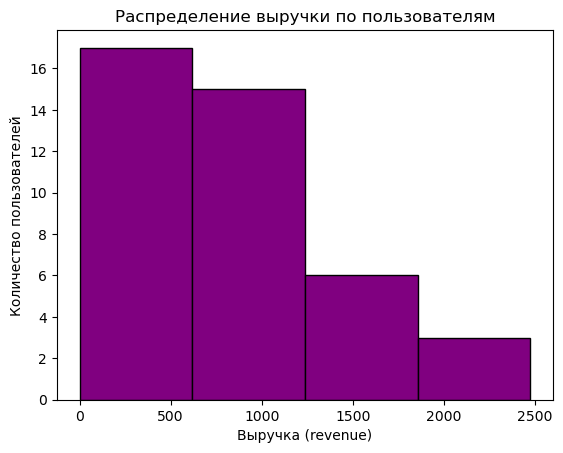

In [33]:
import matplotlib.pyplot as plt
# создаем гистрограмму
plt.hist(df['revenue'], bins=4, color='purple', edgecolor='black')

# Подписи осей и заголовок
plt.xlabel('Выручка (revenue)')
plt.ylabel('Количество пользователей')
plt.title('Распределение выручки по пользователям')

# Показываем график
plt.show()

### ***Задание 2***
>Один боксплот (boxplot) для количественного признака:

>- можно как общий, так и по группам (например, по категориям),
>- подписи оси и заголовок.

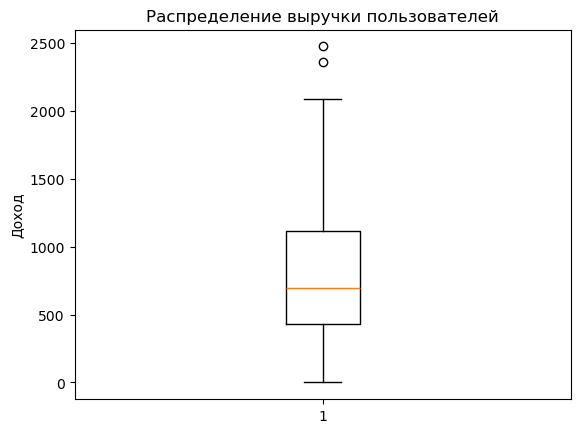

In [35]:
import matplotlib.pyplot as plt

# Создаем боксплот
plt.boxplot(df['revenue'])

# Подписи
plt.ylabel('Доход')
plt.title('Распределение выручки пользователей')

# Показываем график
plt.show()

### ***Задание 3***
>Один scatter plot (диаграмма рассеяния) для пары количественных признаков:

>- подписи обеих осей,
>- заголовок,
>- при желании можно добавить цвет/легенду для различения категорий.


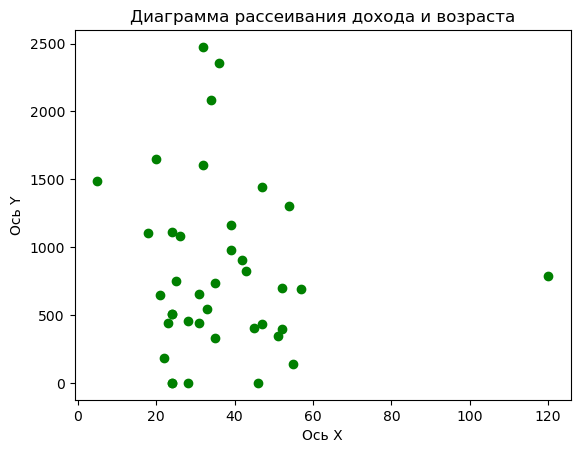

In [37]:
import numpy as np #
import matplotlib.pyplot as plt #

plt.scatter(df['age'],df['revenue'], color='green') # параметры нашей гистаграмы

# подписи осей
plt.xlabel("Ось X")
plt.ylabel("Ось Y")
plt.title("Диаграмма рассеивания дохода и возраста")

plt.show()

### ***Задание 4***
>Сохранить минимум один из построенных графиков в папку homeworks/HW02/figures/:

>- использовать plt.savefig(...) или аналог;
>- убедиться, что файл действительно появляется в репозитории и может быть открыт отдельно от ноутбука.

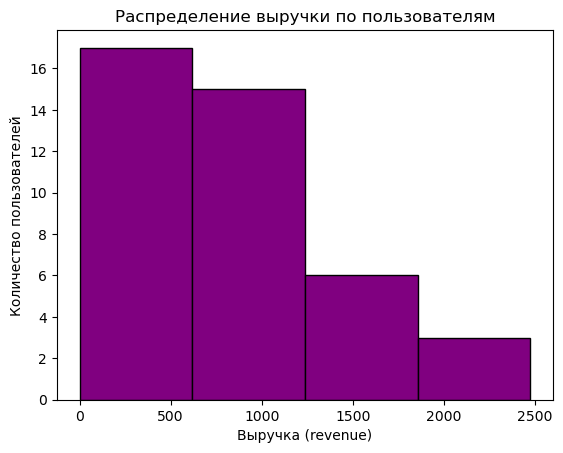

In [39]:
import matplotlib.pyplot as plt
# создаем гистрограмму
plt.hist(df['revenue'], bins=4, color='purple', edgecolor='black')

# Подписи осей и заголовок
plt.xlabel('Выручка (revenue)')
plt.ylabel('Количество пользователей')
plt.title('Распределение выручки по пользователям')

# Показываем график
plt.savefig('plot.png')
plt.show()